In [11]:
#initialization
import matplotlib.pyplot as plt
import numpy as np
import math

# importing Qiskit
from qiskit_aer import Aer
from qiskit import transpile
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister

# import basic plot tools
from qiskit.visualization import plot_histogram

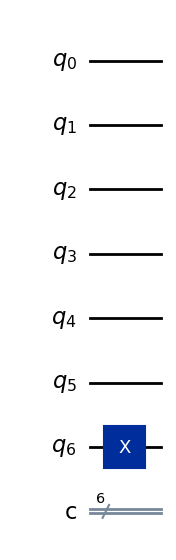

In [12]:
qpe = QuantumCircuit(7, 6)
qpe.x(6)
qpe.draw('mpl')

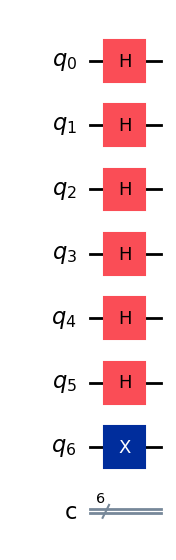

In [13]:
for qubit in range(6):
    qpe.h(qubit)
qpe.draw('mpl')

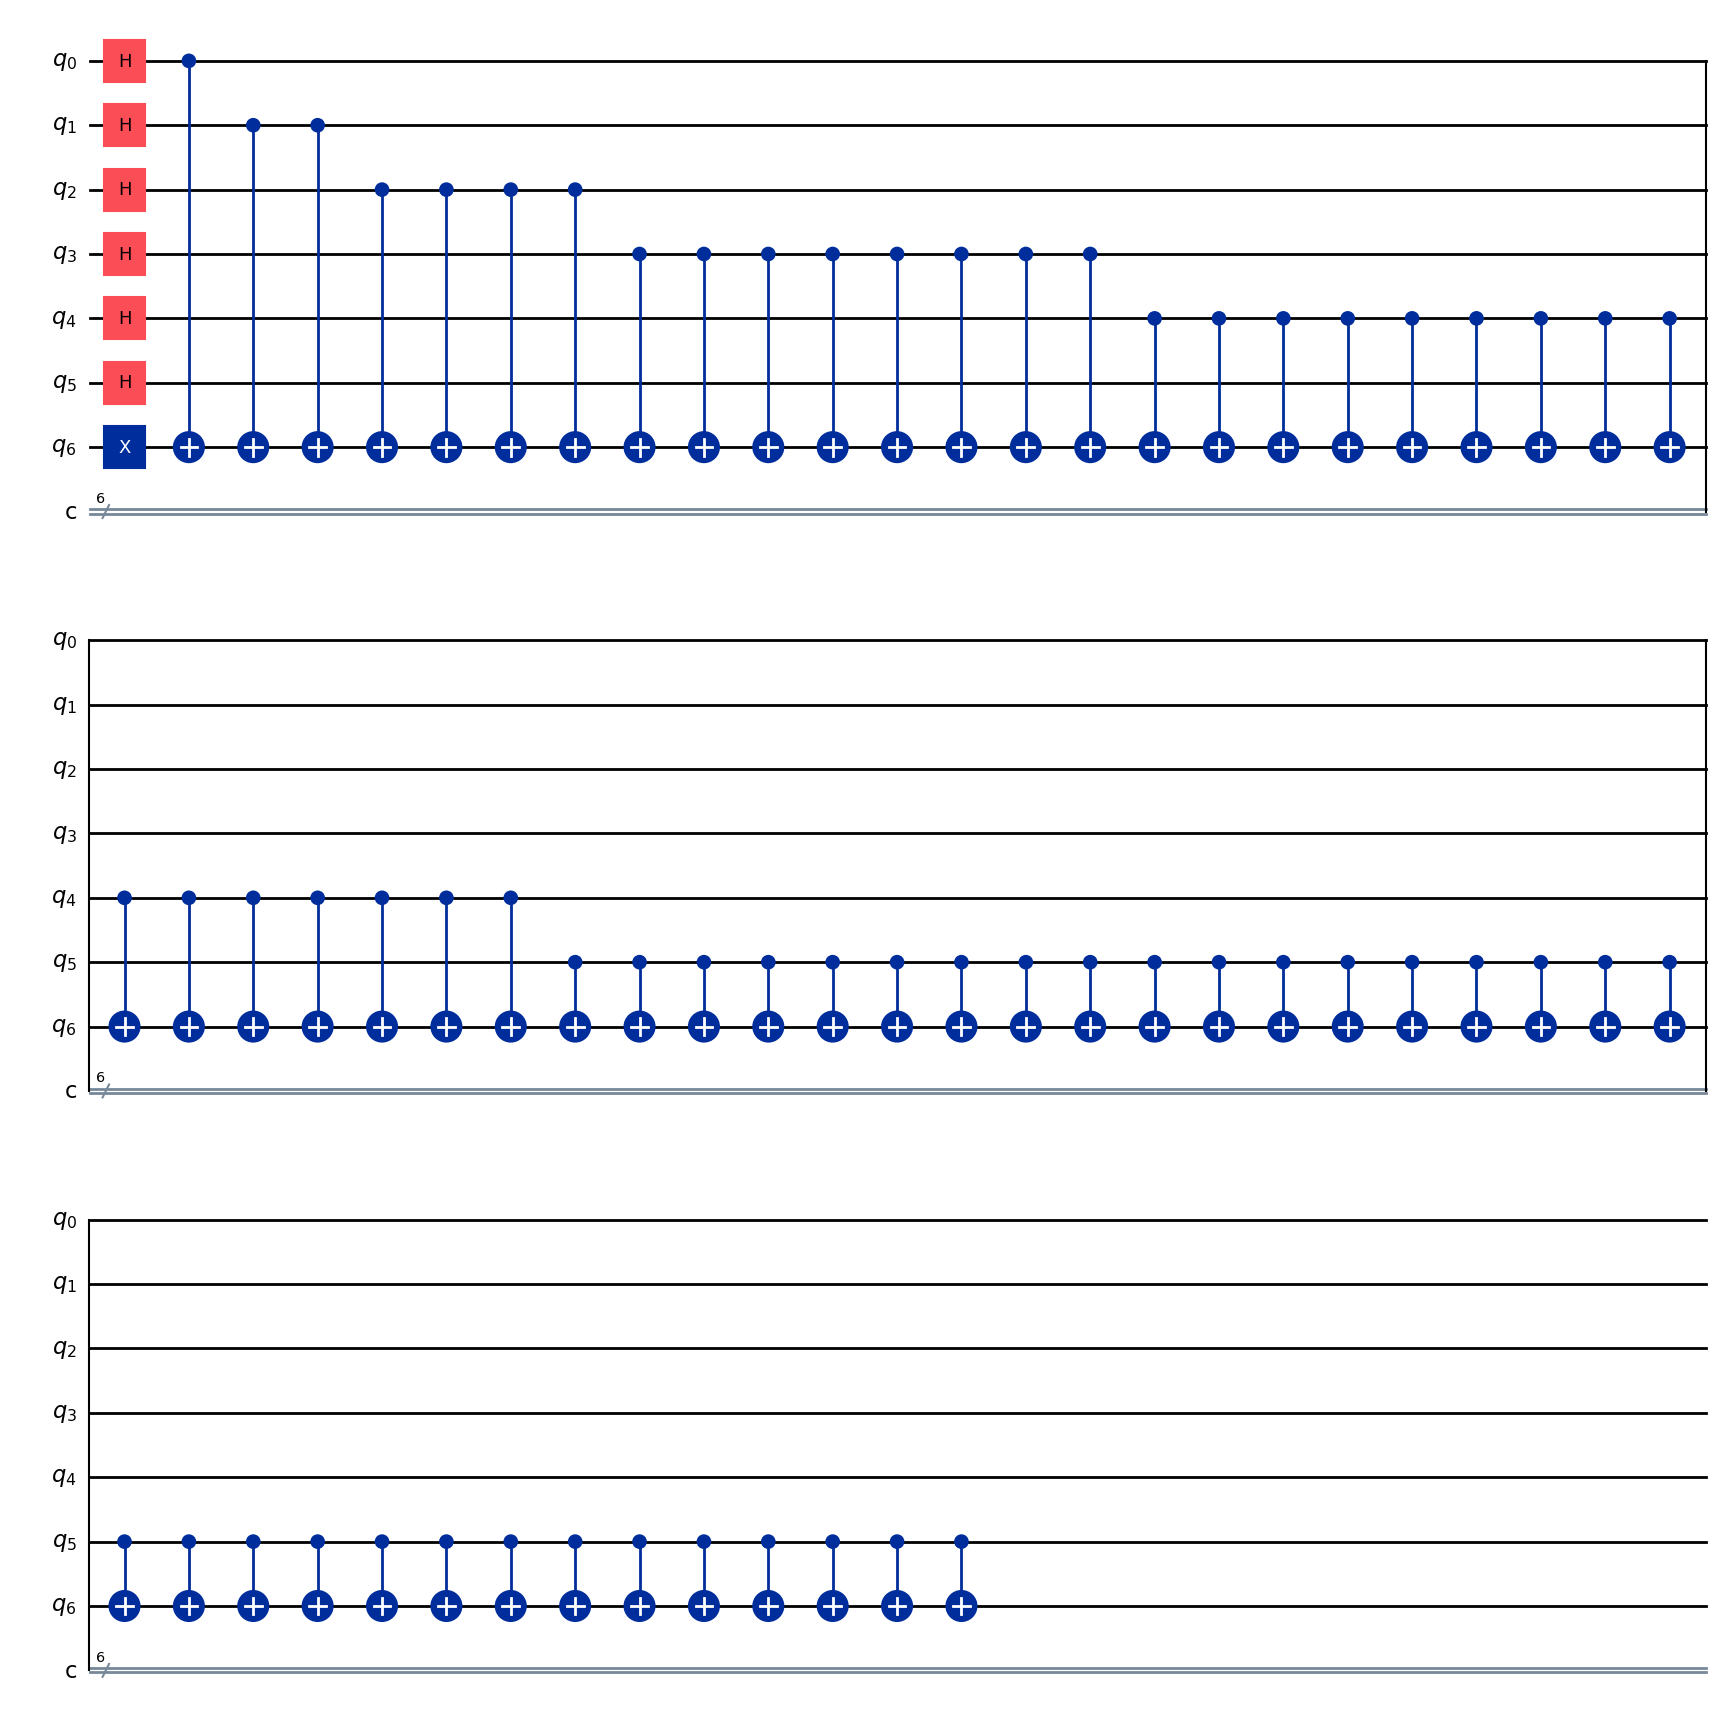

In [14]:
repetitions = 1
for counting_qubit in range(6):
    for i in range(repetitions):
        qpe.cx(counting_qubit, 6)  # Replaced controlled-phase with CNOT
    repetitions *= 2
qpe.draw('mpl')

In [15]:
def qft_dagger(qc, n):
    """n-qubit QFTdagger the first n qubits in circ"""
    # Don't forget the Swaps!
    for qubit in range(n//2):
        qc.swap(qubit, n-qubit-1)
    for j in range(n):
        for m in range(j):
            qc.cp(-math.pi/float(2**(j-m)), m, j)
        qc.h(j)

In [16]:
qpe.barrier()
# Apply inverse QFT
qft_dagger(qpe, 6)
# Measure
qpe.barrier()
for n in range(6):
    qpe.measure(n,n)

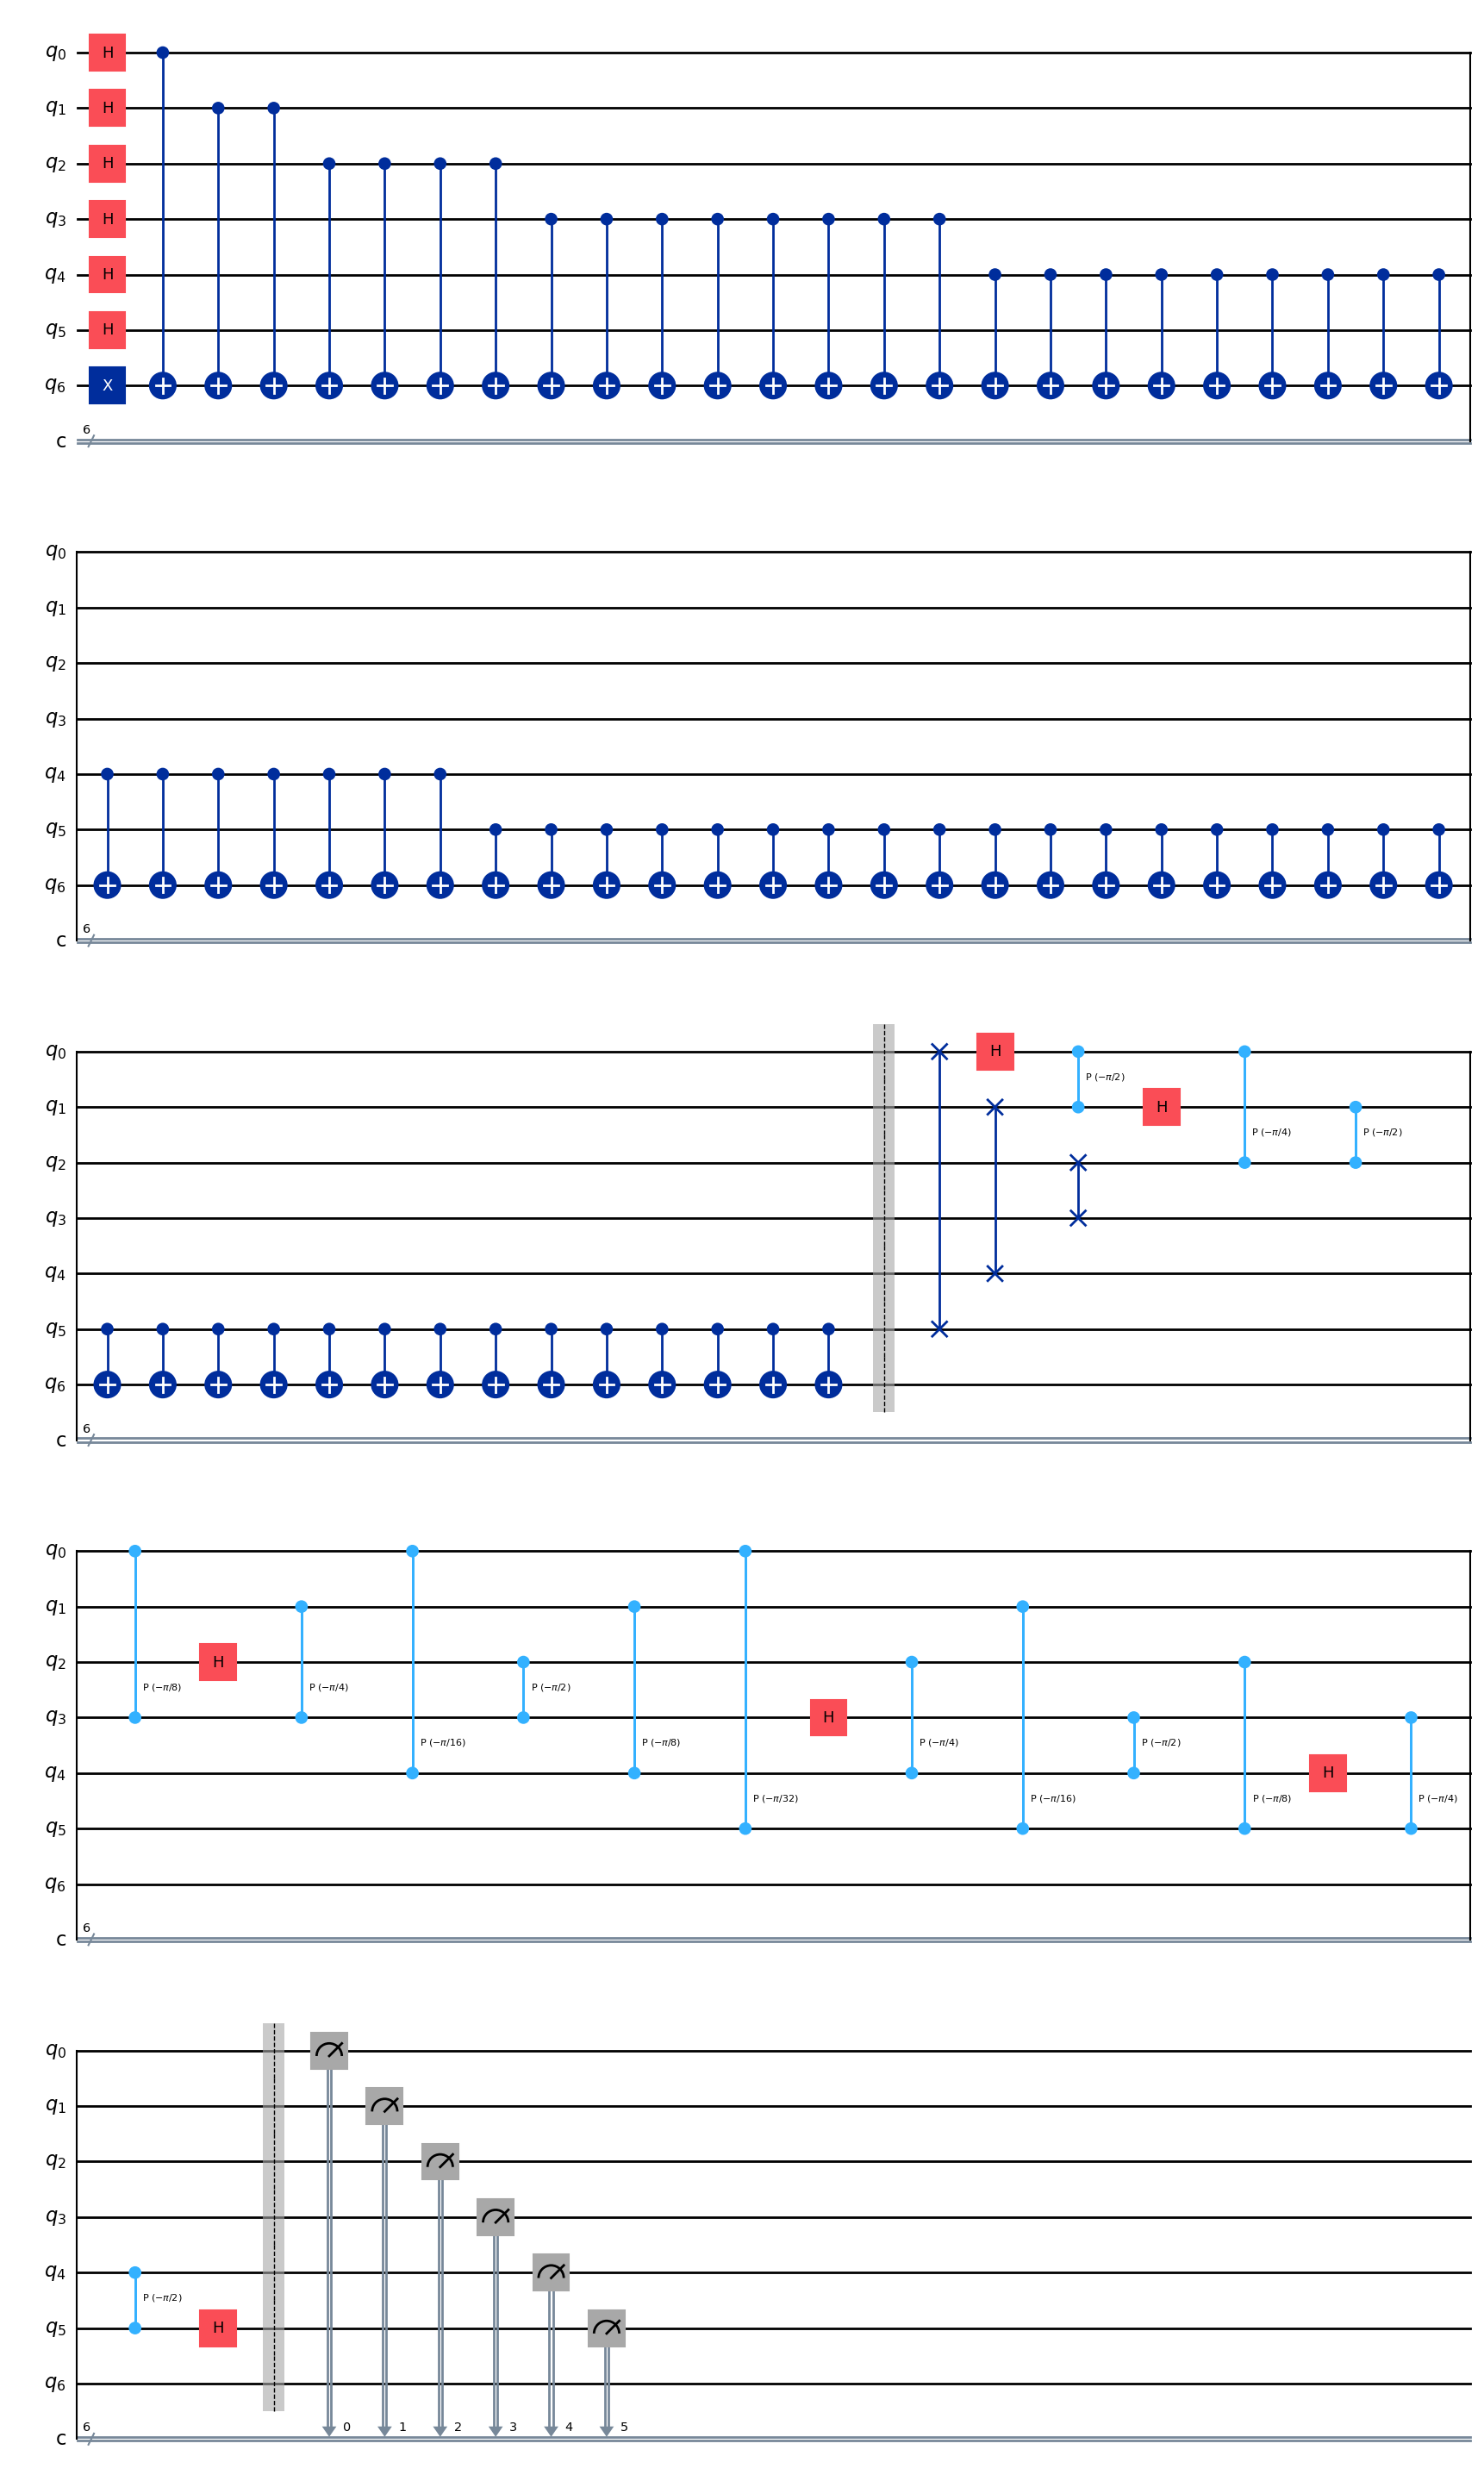

In [17]:
qpe.draw('mpl')

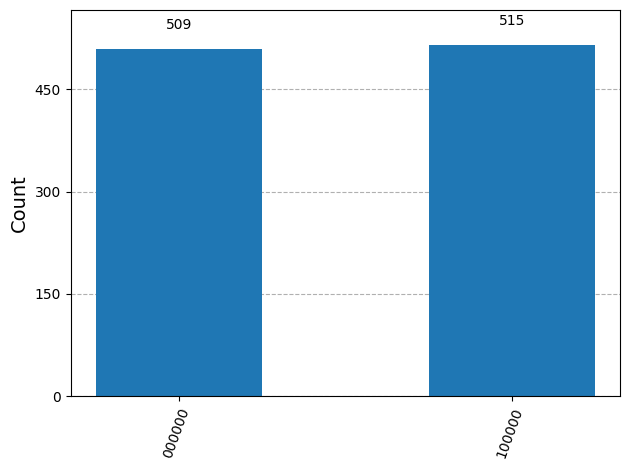

In [18]:
aer_sim = Aer.get_backend('aer_simulator')
shots = 2048
t_qpe = transpile(qpe, aer_sim)
#qobj = assemble(t_qpe, shots=shots)
results = aer_sim.run(t_qpe).result()
answer = results.get_counts()

plot_histogram(answer)